# Hoja de trabajo 1

## Task 1 Análisis Teórico


### 1. Como director de un proyecto de conducción autónoma, debe dimensionar el hardware para un nuevo vehículo. El sistema utiliza 8 cámaras que capturan video a resolución 4K UHD (3840 x 2160).
Debido a la necesidad de alto rango dinámico (HDR), los sensores operan a 12 bits por píxel (Raw
Bayer Pattern) a 60 FPS.Métrica A: Enfocada puramente en el flujo vehicular.

a. Calcule el tamaño exacto de una sola imagen (frame) cruda en Megabytes (MB).

b. Calcule el ancho de banda necesario (en Gbps) para transmitir el flujo de las 8 cámaras al
procesador central sin compresión.

c. Si su procesador tiene una memoria RAM reservada de 16 GB exclusivamente para el buffer
de video, ¿cuántos segundos de historia puede almacenar antes de empezar a sobrescribir
datos?

d. Basado en su resultado, ¿es viable enviar estos datos "crudos" a la nube en tiempo real
usando 5G? Justifique

In [12]:
print("a. ")
res = 3840 * 2160
bpframe = res * 12
print(f"4K resolution is {res} pixels.")
print(f"MegaBytes por imagen= {((res * 12)/8)/1048576}")

a. 
4K resolution is 8294400 pixels.
MegaBytes por imagen= 11.865234375


## Megabytes por imagenes = 11.865234375

In [17]:
print("b. ")
anchoBtotal = bpframe * 60
print(f"ancho total de banda en Gb en 8 camaras = {(anchoBtotal/1000000000)*8}")



b. 
ancho total de banda en Gb en 8 camaras = 47.775744


## Datos por seg por 8 cams en Gb/s = 47.78Gb/s

In [22]:
ramMb = 16384
DpS8Cams = 712.2*8

print(f"c. {ramMb/DpS8Cams}" )


c. 2.875596742488065


## Puede almacenar aprox. 2.9 segundos de video crudo

No es viable transmitir en tiempo real a la nube el flujo de video crudo generado por las 8 cámaras utilizando 5G.

El sistema produce aproximadamente 45.6 Gbps de datos continuos, mientras que las redes 5G, incluso en condiciones ideales, ofrecen velocidades máximas teóricas del orden de 20 Gbps, y en escenarios reales de movilidad vehicular el ancho de banda efectivo suele estar entre 1 y 3 Gbps, con latencias variables y posibles pérdidas de conexión.

Por estas razones, el procesamiento debe realizarse localmente.

### Considere un píxel con valor de intensidad Iin=50 en una imagen estándar de 8 bits (0−255). Se aplican dos procesos de mejora secuenciales en el siguiente orden:
### I. Corrección Gamma con γ=0.5 (para expandir sombras).
### II. Ajuste Lineal con ganancia α=1.2 y brillo β=-10 (para contrastar).

Realice los cálculos en el dominio de flotantes normalizados [0,1] como dicta la buena práctica y
convierta a entero de 8 bits solo al final.

a. Calcule el valor final del píxel I_out.

b. ¿Hubo saturación (clipping) en el proceso?

c. Si hubiéramos realizado las operaciones usando uint8 directamente sin convertir a float
(truncando decimales en cada paso intermedio), ¿cuál habría sido el error numérico
resultante?

In [ ]:
I = 50
Ii = 50/255
gamma = 0.5
alfa = 1.2
beta = -10

Ic = Ii**gamma
print(f"correccion gamma: {Ic}")

Bnorm = beta/255

Isalida = alfa * Ic + Bnorm
print(f"imagen de salida: {Isalida*255}")




correccion gamma: 0.44280744277004763
imagen de salida: 125.49907748763458


### a. El valor final del pixel es de aprox. 126

### b. No hubo stranding, porque el valor intermedio siempre estuvo dentro de 0 y 1 y el final dentro de 255

### c. El resultado final hubiera sido el 125 o sea 1 valor de intensidad

# Task 3 Tarea 1 - Robot clasificador de pelotas - comparación de color (RGB vs HSV)

Se tienen dos observaciones del **mismo objeto** (una pelota roja), pero bajo condiciones de iluminación distintas:

- **Rojo brillante al sol:** $R_{rgb}=(255,0,0)$  
- **Rojo en sombra profunda:** $S_{rgb}=(50,0,0)$  

---

## a) Distancia entre ambos colores en el espacio RGB

Se usa la distancia Euclidiana en 3D:

$$
d_{RGB}(R,S)=\sqrt{(R_r-S_r)^2+(R_g-S_g)^2+(R_b-S_b)^2}
$$

Sustituyendo valores:

$$
d_{RGB}(R,S)=\sqrt{(255-50)^2+(0-0)^2+(0-0)^2}
$$

$$
d_{RGB}(R,S)=\sqrt{205^2} = 205
$$

**Resultado:**  
- $d_{RGB}=205$

---

## b) Conversión de ambos colores a HSV (normalizado)

Se asume el espacio HSV normalizado:

- $H\in[0,1]$
- $S\in[0,1]$
- $V\in[0,1]$

Y se usa que el **Hue del rojo** es:

$$
H_{rojo}=0
$$

### 1) Para $R_{rgb}=(255,0,0)$

- Máximo: $\max = 255$
- Mínimo: $\min = 0$

Valor:

$$
V=\frac{\max}{255}=\frac{255}{255}=1
$$

Saturación:

$$
S=\frac{\max-\min}{\max}=\frac{255-0}{255}=1
$$

Hue (rojo):

$$
H=0
$$

✅ **Resultado:**
- $R_{hsv}=(0,\;1,\;1)$

---

### 2) Para $S_{rgb}=(50,0,0)$

- Máximo: $\max = 50$
- Mínimo: $\min = 0$

Valor:

$$
V=\frac{\max}{255}=\frac{50}{255}\approx 0.1961
$$

Saturación:

$$
S=\frac{\max-\min}{\max}=\frac{50-0}{50}=1
$$

Hue (rojo):

$$
H=0
$$

✅ **Resultado:**
- $S_{hsv}=(0,\;1,\;0.1961)$

---

## c) Diferencia absoluta canal por canal en HSV

Se calcula:

$$
\Delta H = |H_R - H_S|,\quad
\Delta S = |S_R - S_S|,\quad
\Delta V = |V_R - V_S|
$$

Sustituyendo:

$$
\Delta H = |0-0| = 0
$$

$$
\Delta S = |1-1| = 0
$$

$$
\Delta V = |1-0.1961| \approx 0.8039
$$

**Resultado:**
- $\Delta HSV = (0,\;0,\;0.8039)$

---

## d) Por qué clustering simple fallaría en RGB pero funcionaría en HSV

### ✅ Problema en RGB (fallo)

Un clustering simple (ej. *k-means*) suele agrupar usando distancia Euclidiana en el espacio original.  
En RGB, los dos puntos son:

- $R=(255,0,0)$
- $S=(50,0,0)$

La distancia Euclidiana calculada fue:

$$
d_{RGB}(R,S)=205
$$

Esto es **muy grande** porque RGB mezcla en el mismo espacio:

- **color real**
- **brillo / iluminación**

En este caso, el cambio de iluminación afecta fuertemente al canal rojo ($R$), por lo que el algoritmo interpreta:

> “Son colores distintos”  
aunque en realidad es **el mismo objeto** con distinta luz.

Matemáticamente, el término dominante en la distancia es:

$$
(255-50)^2 = 205^2
$$

y por eso la distancia total se vuelve grande aunque el “tono” sea el mismo.

---

### ✅ Ventaja en HSV (funciona)

En HSV, el color se separa en componentes más interpretables:

- $H$ = tono (qué color es)
- $S$ = saturación (qué tan puro es)
- $V$ = brillo (iluminación)

Los valores obtenidos fueron:

- $R_{hsv}=(0,\;1,\;1)$
- $S_{hsv}=(0,\;1,\;0.1961)$

Aquí se observa que:

- $H$ no cambia: $0 \rightarrow 0$
- $S$ no cambia: $1 \rightarrow 1$
- solo cambia el brillo $V$: $1 \rightarrow 0.1961$

En otras palabras:

$$
(H,S) \text{ se mantiene constante}
$$

y el cambio ocurre solo por iluminación:

$$
V \text{ disminuye por sombra}
$$

Por eso un clustering que agrupe según el “color real” puede usar principalmente $(H,S)$, y ambos píxeles caen en el mismo grupo:

$$
\Delta H=0,\quad \Delta S=0
$$

📌 Conclusión matemática:

- En **RGB**, la métrica queda dominada por cambios de iluminación:
  $$
  d_{RGB}(R,S)=205 \;\;(\text{grande})
  $$

- En **HSV**, el “color” permanece igual y solo varía el brillo:
  $$
  \Delta(H,S)=(0,0)\;\;(\text{idéntico})
  $$

✅ Por eso, **RGB tiende a separar** ambos píxeles en clusters distintos, mientras que **HSV permite agruparlos** como el mismo objeto “pelota roja”.


## Task 2 Práctica

In [1]:
import numpy as np

def manual_contrast_brightness(image, alpha, beta):
    """
    Ajuste manual de contraste y brillo usando NumPy (vectorizado).
    
    Params:
        image: np.ndarray uint8 (H,W) o (H,W,C)
        alpha: float (contraste)
        beta: float (brillo en escala normalizada [0,1])
        
    Returns:
        np.ndarray uint8 con el ajuste aplicado
    """
    img_f = image.astype(np.float32)          # uint8 -> float32
    img_norm = img_f / 255.0                 # normaliza a [0,1]
    out = alpha * img_norm + beta            # g(x) = alpha*f(x) + beta
    out = np.clip(out, 0.0, 1.0)             # clipping [0,1]
    out_u8 = (out * 255.0).astype(np.uint8)  # regresa a uint8 [0,255]
    return out_u8


In [2]:
import numpy as np

def manual_gamma_correction(image, gamma):
    """
    Corrección gamma manual usando NumPy (vectorizado).
    
    Ecuación:
        Vout = Vin^gamma
    
    Pipeline:
        uint8 -> float32 -> normaliza [0,1] -> potencia -> clip [0,1] -> uint8
    """
    img_f = image.astype(np.float32)         # uint8 -> float32
    img_norm = img_f / 255.0                # normaliza a [0,1]
    out = np.power(img_norm, gamma)         # Vin^gamma (vectorizado)
    out = np.clip(out, 0.0, 1.0)            # clipping [0,1]
    out_u8 = (out * 255.0).astype(np.uint8) # regresa a uint8
    return out_u8


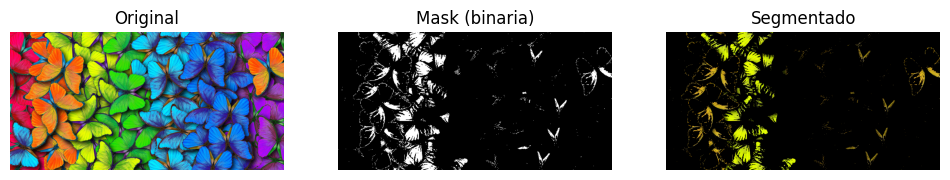

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def hsv_segmentation(image):
    """
    Segmentación cromática manual en HSV (vectorizado).
    Devuelve:
      - mask: binaria (0 o 255)
      - segmented: objeto aislado sobre fondo negro
    """
    # 1) BGR -> HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # 2) Rangos manuales (EJEMPLO: Amarillo tipo "banano")
    # OpenCV HSV: H [0,179], S [0,255], V [0,255]
    lower_bound = np.array([20, 80, 80], dtype=np.uint8)
    upper_bound = np.array([35, 255, 255], dtype=np.uint8)

    # 3) Máscara binaria manual (sin cv2.inRange)
    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    cond = (
        (h >= lower_bound[0]) & (h <= upper_bound[0]) &
        (s >= lower_bound[1]) & (s <= upper_bound[1]) &
        (v >= lower_bound[2]) & (v <= upper_bound[2])
    )

    mask = (cond.astype(np.uint8) * 255)

    # 4) Aplicar máscara (objeto sobre fondo negro)
    segmented = np.zeros_like(image, dtype=np.uint8)
    segmented[cond] = image[cond]

    return mask, segmented


# ============================
# USO con "imagenprueba.jpg"
# ============================

img_bgr = cv2.imread("imagenprueba.jpg")

if img_bgr is None:
    raise FileNotFoundError("No se encontró 'imagenprueba.jpg' en el directorio actual.")

mask, segmented_bgr = hsv_segmentation(img_bgr)

# Mostrar resultados (convertir a RGB para matplotlib)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
segmented_rgb = cv2.cvtColor(segmented_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask (binaria)")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Segmentado")
plt.imshow(segmented_rgb)
plt.axis("off")

plt.show()


## Task 3 Preguntas Post-Práctica



# Respuestas

## 1) ¿Por qué “iterar píxel a píxel en Python es un Pecado Capital”?

Iterar píxel a píxel con un `for` en Python suele ser lento porque el intérprete tiene que ejecutar muchas operaciones adicionales en cada iteración, incluso si la operación matemática es simple. En una imagen hay cientos de miles o millones de píxeles, por lo que ese costo se acumula rápidamente. En cambio, NumPy permite operar sobre toda la matriz en una sola instrucción, y esas operaciones se ejecutan en rutinas compiladas (por ejemplo en C), que son mucho más eficientes.

En términos de CPU, un `for` implica overhead constante: control del ciclo, verificación de tipos, indexación y ejecución de lógica por cada píxel. Esto hace que una parte importante del tiempo se gaste en la gestión del loop, no en el cálculo. Con NumPy, la operación se aplica de forma vectorizada y el trabajo pesado se delega a código optimizado, reduciendo el overhead del intérprete.

En términos de memoria, los arreglos de NumPy almacenan datos de forma contigua, lo cual mejora el rendimiento porque el procesador aprovecha mejor la caché y puede procesar bloques completos de datos. En un ciclo que accede elemento por elemento, el acceso es menos eficiente y no se aprovecha igual el procesamiento por bloques. Por estas razones, una operación vectorizada con NumPy puede ser órdenes de magnitud más rápida que un `for` en Python.

---

## 2) Al visualizar imágenes con matplotlib, ¿qué sucede si se olvida que OpenCV carga las imágenes en formato BGR? ¿Cómo se ve visualmente el error?

OpenCV carga imágenes en formato BGR, mientras que `matplotlib.pyplot.imshow()` interpreta la imagen en formato RGB. Si se visualiza la imagen directamente sin convertirla, los canales rojo y azul quedan intercambiados.

Visualmente, esto provoca colores incorrectos. Objetos que deberían verse rojos tienden a verse azules, y objetos azules tienden a verse rojizos. En general, la imagen se ve con tonalidades poco naturales debido a la inversión de esos canales.

La forma correcta de evitarlo es convertir la imagen de BGR a RGB antes de mostrarla

## **La pregunta 3 es la misma que la 2**